Newmark Integration: 100%|██████████| 9000/9000 [01:23<00:00, 108.34step/s]


X shape: (9001,) Y shape: (9001, 211) freq shape: (9001,) veloc shape: (9001, 211)
COMSOL data not loaded: name 'pd' is not defined


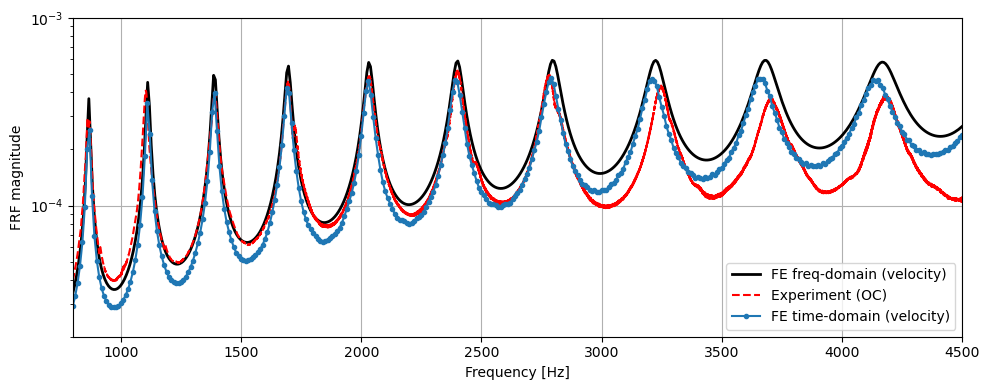

In [18]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
import Modeling
importlib.reload(Modeling)
from Modeling.models.plotting import animate_field_1d
from Modeling.models.beam_properties import PiezoBeamParams


from Modeling.models import FE_helpers 
import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM

import Modeling.models.FE2 as FE_module
importlib.reload(FE_module)
FE = FE_module

K_i = 1800; K_p = 0.0025; K_c = 0; R_c = 1e3
K_i = 0; K_p = 5000; K_c = 0; R_c = 1e3
K_i = 0; K_p = 1e-5; K_c = 0; R_c = 1e3
t_end = 0.1
f0 = 800
f1 = 4500
dt = 1/f1/20
def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
# N = 40
# hp, hs = 0.31e-3, 0.607e-3 		
params_fe = PiezoBeamParams(
                            hp=0.252e-3, hs=0.51e-3
                            # hp=0.31e-3, hs=0.607e-3
                            , d31= -1.48e-10,eps_r=1700
                            )
params_fe.zeta_p = 0.0151*8
params_fe.zeta_q = 0.0392*10

geom = FE_module.geometry_from_params(
	params=params_fe,
	h_patch=2e-3,   # fine mesh under piezos
	h_gap=5e-3      # coarser mesh in gaps
)

params_fe.geometry = geom   # optional, but supported by PiezoBeamFE

fe = FE_module.PiezoBeamFE(params_fe)

ode = fe.build_ode_system(
    j_exc=30,
    K_c=K_c,    # linear circuit
    K_i=K_i,
    K_p= K_p,
	v_exc=v_exc
)
f_fe = np.linspace(f0, f1, 500)
frf_fd = FE_helpers.frf_sweep(ode, f_fe*2*np.pi)
N = ode.N_mech
w_fd = frf_fd['u']
w_dot_fd = frf_fd['u_dot']


# time grid and ICs
t_eval = np.arange(0, t_end, dt)
ndof = ode.M.shape[0]

x0 = np.zeros(ndof)
x_dot0 = np.zeros(ndof)

result = FE_helpers.solve_newmark(
	ode=ode,
	dt=dt,
	t_end=t_end,
	beta=0.25,
	gamma=0.5,
	newton_tol=1e-8,
	newton_maxiter=8,
	x0=x0,
	x_dot0=x_dot0
	)

# Extract results from dictionary
t = result['t']
w = result['u']                # mechanical displacement
w_dot = result['u_dot']        # mechanical velocity
w_ddot = result['u_ddot']      # mechanical acceleration
q = result['q']                # electrical charge
v = result['v']                # voltage
spec_td = result['spectral']   # time-domain FRF dictionary (freq, FRF)
# Frequency-domain vs time-domain FRF overlay with experimental/COMSOL
try:
    # Load experimental datasets (same as FE_OC)
    npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\OC.npz".replace("\\", "/")
    npz_path_SC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz".replace("\\", "/")
    npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz".replace("\\", "/")
    npz_path_linear = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear_lowdamping.npz".replace("\\", "/")
    data_OC = np.load(npz_path_OC)
    data_SC = np.load(npz_path_SC)
    data_linear = np.load(npz_path_linear)
    frq_OC_exp = data_OC['freq']
    frf_OC_exp = data_OC['frf_data']  # (Nfiles, Nfreq, Npoints)
    frq_SC_exp = data_SC['freq']
    frf_SC_exp = data_SC['frf_data']
    frq_linear_exp = data_linear['freq']
    frf_linear_exp = data_linear['frf_data']
except Exception as e:
    print("Experimental data not loaded:", e)
    frq_OC_exp = frf_OC_exp = frq_SC_exp = frf_SC_exp = frq_linear_exp = frf_linear_exp = None

# COMSOL reference
try:
    comsol = pd.read_csv('../../../comsol/LR.csv')
    # comsol = pd.read_csv('../../../comsol/SC.csv')
except Exception as e:
    print("COMSOL data not loaded:", e)
    comsol = None

# Frequency-domain FE FRF (velocity magnitude averaged over transverse DOFs)
freq_fd = frf_fd['freq']
vel_fd = np.mean(np.abs(w_dot_fd), axis=1)

# Time-domain FRF from transient (if available)
if spec_td is not None and spec_td['freq'] is not None:
    freq_td = spec_td['freq']
    frf_td = spec_td['FRF']
else:
    freq_td = None
    frf_td = None

plt.figure(figsize=(10, 4))

# plt.semilogy(comsol['freq'], comsol['w']*2*np.pi*comsol['freq'], 'g-', label='COMSOL')
# plt.semilogy(frq_linear_exp, np.mean(frf_linear_exp, axis=1), 'r--', label='Experiment (linear)')
plt.semilogy(freq_fd, vel_fd/1.2,'k-' , lw=2, label='FE freq-domain (velocity)')
plt.semilogy(frq_OC_exp, np.mean(frf_OC_exp, axis=1), 'r--', label='Experiment (OC)')
# plt.semilogy(frq_SC_exp, np.mean(frf_SC_exp, axis=1), 'r--', label='Experiment (SC)')
plt.semilogy(freq_td, frf_td/1.5, '.-', label='FE time-domain (velocity)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude')
plt.xlim([1000, 3000])
plt.xlim([f0, f1])
plt.ylim([2e-5, 1e-3])
plt.grid(True)
plt.legend()
# plt.title('FRF overlay: experimental, COMSOL, FE (freq), FE (time)')
plt.tight_layout()
plt.show()


In [19]:
def create_arbitrary_geometry(
	L: float,
	xL: np.ndarray,
	xR: np.ndarray,
	b: float,
	hs: float,
	hp: float,
	rho_s: float,
	rho_p: float,
	E_s: float,
	E_p: float,
	h_patch: float,
	h_gap: float
):
	"""
	Create a fully arbitrary piezo-beam geometry with
	region-dependent EI and rhoA.
	"""

	# ---- mass per unit length ----
	rhoA_gap = b * rho_s * hs
	rhoA_patch = b * (rho_s * hs + 2.0 * rho_p * hp)

	# ---- bending stiffness ----
	EI_gap = b * E_s * hs**3 / 12

	term1 = E_s * hs**3 / 8
	term2 = E_p * ((hp + hs/2)**3 - hs**3/8)
	EI_patch = 2.0 * b / 3.0 * (term1 + term2)

	return FE_module.build_geometry_arbitrary_piezos(
		L=L,
		xL=xL,
		xR=xR,
		EI_patch=EI_patch,
		rhoA_patch=rhoA_patch,
		EI_gap=EI_gap,
		rhoA_gap=rhoA_gap,
		h_patch=h_patch,
		h_gap=h_gap
	)
geom = create_arbitrary_geometry(
	L=400e-3,
	xL=np.array([5, 100, 200])*1e-3,
	xR=np.array([30, 125, 225])*1e-3 ,
	b=10e-3,
	hs=0.5e-3,
	hp=0.5e-3,
	rho_s=1190,
	rho_p=7800,
	E_s=1e9,
	E_p=62e9,
	h_patch=2e-3,
	h_gap=0.5e-3
)
params_fe.geometry = geom   # optional, but supported by PiezoBeamFE

fe = FE_module.PiezoBeamFE(params_fe)

ode = fe.build_ode_system(
    j_exc=30,
    K_c=K_c,    # linear circuit
    K_i=K_i,
    K_p= K_p,
	v_exc=v_exc
)
f_fe = np.linspace(f0, f1, 500)
frf_fd = FE_helpers.frf_sweep(ode, f_fe*2*np.pi)
N = ode.N_mech
w_fd = frf_fd['u']
w_dot_fd = frf_fd['u_dot']


# time grid and ICs
t_eval = np.arange(0, t_end, dt)
ndof = ode.M.shape[0]

x0 = np.zeros(ndof)
x_dot0 = np.zeros(ndof)

result = FE_helpers.solve_newmark(
	ode=ode,
	dt=dt,
	t_end=t_end,
	beta=0.25,
	gamma=0.5,
	newton_tol=1e-8,
	newton_maxiter=8,
	x0=x0,
	x_dot0=x_dot0
	)

# Extract results from dictionary
t = result['t']
w = result['u']                # mechanical displacement
w_dot = result['u_dot']        # mechanical velocity
w_ddot = result['u_ddot']      # mechanical acceleration
q = result['q']                # electrical charge
v = result['v']                # voltage
spec_td = result['spectral']   # time-domain FRF dictionary (freq, FRF)
# Frequency-domain vs time-domain FRF overlay with experimental/COMSOL
try:
    # Load experimental datasets (same as FE_OC)
    npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\OC.npz".replace("\\", "/")
    npz_path_SC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz".replace("\\", "/")
    npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz".replace("\\", "/")
    npz_path_linear = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear_lowdamping.npz".replace("\\", "/")
    data_OC = np.load(npz_path_OC)
    data_SC = np.load(npz_path_SC)
    data_linear = np.load(npz_path_linear)
    frq_OC_exp = data_OC['freq']
    frf_OC_exp = data_OC['frf_data']  # (Nfiles, Nfreq, Npoints)
    frq_SC_exp = data_SC['freq']
    frf_SC_exp = data_SC['frf_data']
    frq_linear_exp = data_linear['freq']
    frf_linear_exp = data_linear['frf_data']
except Exception as e:
    print("Experimental data not loaded:", e)
    frq_OC_exp = frf_OC_exp = frq_SC_exp = frf_SC_exp = frq_linear_exp = frf_linear_exp = None

# COMSOL reference
try:
    comsol = pd.read_csv('../../../comsol/LR.csv')
    # comsol = pd.read_csv('../../../comsol/SC.csv')
except Exception as e:
    print("COMSOL data not loaded:", e)
    comsol = None

# Frequency-domain FE FRF (velocity magnitude averaged over transverse DOFs)
freq_fd = frf_fd['freq']
vel_fd = np.mean(np.abs(w_dot_fd), axis=1)

# Time-domain FRF from transient (if available)
if spec_td is not None and spec_td['freq'] is not None:
    freq_td = spec_td['freq']
    frf_td = spec_td['FRF']
else:
    freq_td = None
    frf_td = None

plt.figure(figsize=(10, 4))

# plt.semilogy(comsol['freq'], comsol['w']*2*np.pi*comsol['freq'], 'g-', label='COMSOL')
# plt.semilogy(frq_linear_exp, np.mean(frf_linear_exp, axis=1), 'r--', label='Experiment (linear)')
plt.semilogy(freq_fd, vel_fd/1.2,'k-' , lw=2, label='FE freq-domain (velocity)')
plt.semilogy(frq_OC_exp, np.mean(frf_OC_exp, axis=1), 'r--', label='Experiment (OC)')
# plt.semilogy(frq_SC_exp, np.mean(frf_SC_exp, axis=1), 'r--', label='Experiment (SC)')
plt.semilogy(freq_td, frf_td/1.5, '.-', label='FE time-domain (velocity)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude')
plt.xlim([1000, 3000])
plt.xlim([f0, f1])
plt.ylim([2e-5, 1e-3])
plt.grid(True)
plt.legend()
# plt.title('FRF overlay: experimental, COMSOL, FE (freq), FE (time)')
plt.tight_layout()
plt.show()



IndexError: index 30 is out of bounds for axis 0 with size 3